# EEG Preprocessing & Spectral Slope

This notebook focuses on preprocessing EEG data recorded during deep sleep and extracting spectral properties related to unconscious brain states.

Main goals:
- EEG filtering
- artifact inspection
- spectral analysis
- estimation of spectral exponent (1/f slope)

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [14]:
raw = mne.io.read_raw_brainvision(
    "data/raw/sleep_data/sub_23/eeg/sub-23_task-sleep_run-3_eeg.vhdr",
    preload=True
)

Extracting parameters from data/raw/sleep_data/sub_23/eeg/sub-23_task-sleep_run-3_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 4601199  =      0.000 ...   920.240 secs...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25380\1472620213.py:1: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(


In [15]:
raw

<RawBrainVision | sub-23_task-sleep_run-3_eeg.eeg, 32 x 4601200 (920.2 s), ~1.10 GiB, data loaded>

In [16]:
raw.set_channel_types(
    {ch: "eeg" for ch in raw.ch_names}
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25380\1125738844.py:1: RuntimeWarning: The unit for channel(s) C3, C4, CP1, CP2, CP5, CP6, Cz, ECG, EOG, F3, F4, F7, F8, FC1, FC2, FC5, FC6, Fp1, Fp2, Fz, O1, O2, Oz, P3, P4, P7, P8, Pz, T7, T8, TP10, TP9 has changed from NA to V.
  raw.set_channel_types(


<RawBrainVision | sub-23_task-sleep_run-3_eeg.eeg, 32 x 4601200 (920.2 s), ~1.10 GiB, data loaded>

## EEG Filtering

Applying band-pass filtering between 0.5–45 Hz to remove:
- slow drifts
- DC offset
- high-frequency noise

In [17]:
filtered = raw.copy().filter(
    l_freq=0.5,
    h_freq=45
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 33001 samples (6.600 s)



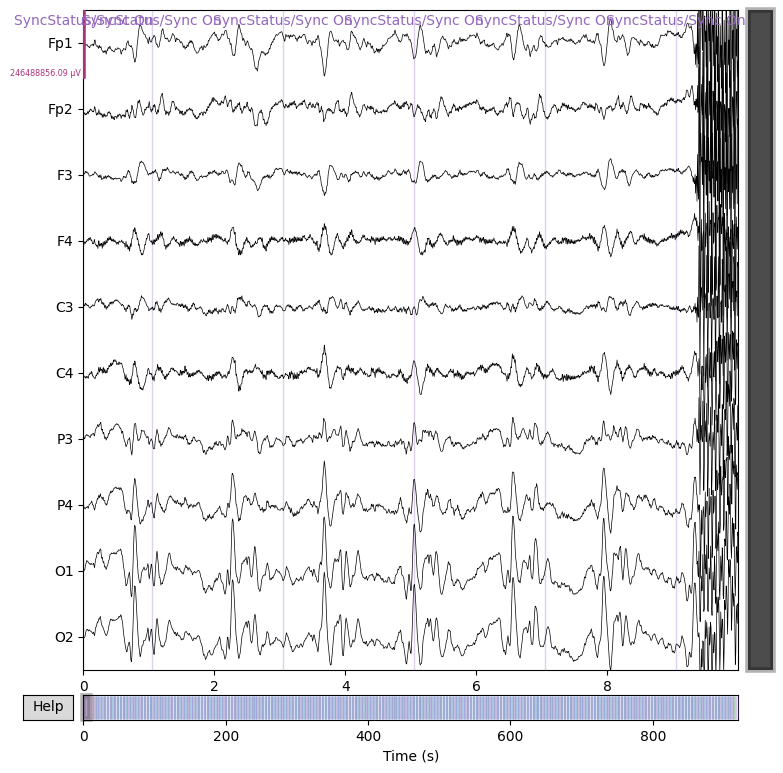

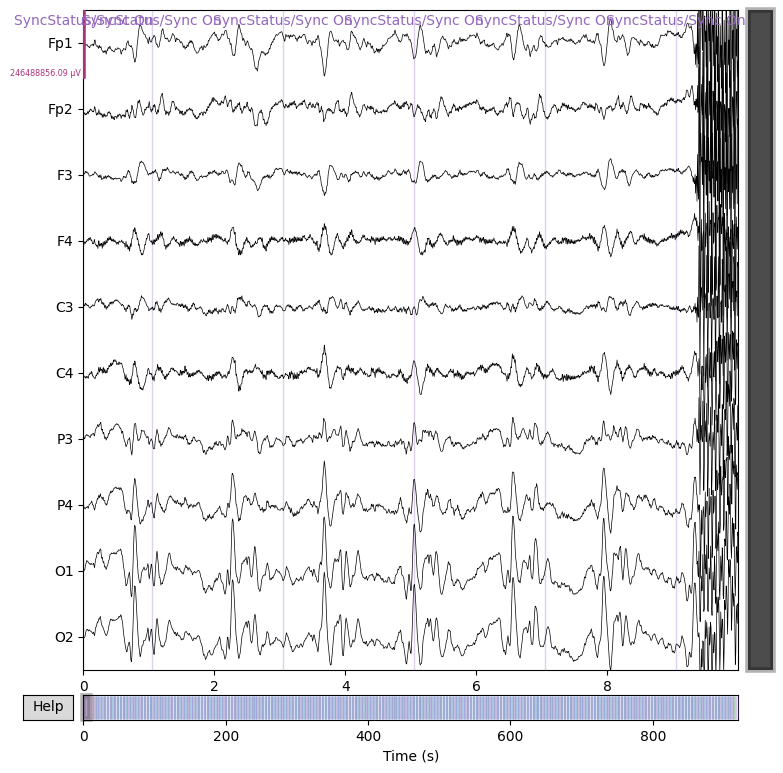

In [25]:
real_eeg = [
    "Fp1", "Fp2",
    "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2"
]

filtered.plot(
    picks=real_eeg,
    duration=10,
    scalings='auto'
)

## Power Spectral Density

Estimating EEG spectral power distribution across frequencies.

Effective window size : 0.410 (s)
Plotting power spectral density (dB=True).


C:\Users\Lenovo\Desktop\data_prjcts\different-paths-to-unresponsiveness\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


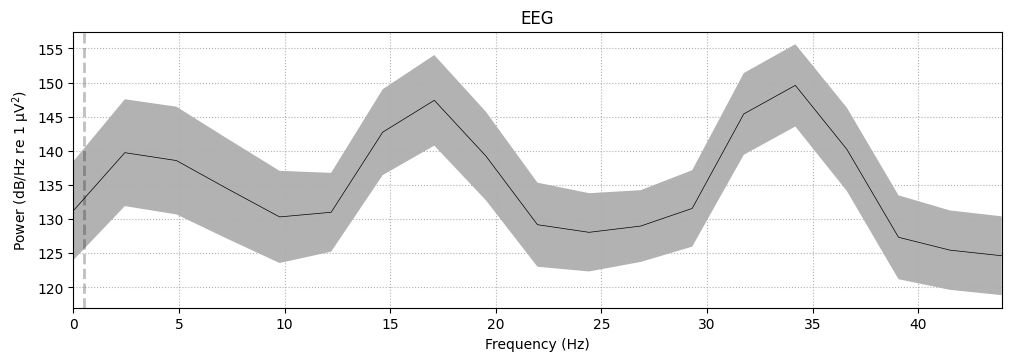

In [26]:
psd = filtered.compute_psd(fmax=45)

psd.plot(average=True)

## Spectral Exponent Estimation

Approximating the EEG power spectrum using a power-law relationship:

P(f) ~ 1 / f^β

where β reflects the steepness of spectral decay.

In [27]:
freqs = psd.freqs
powers = psd.get_data().mean(axis=0)

mask = (freqs >= 30) & (freqs <= 45)

x = freqs[mask]
y = powers[mask]

In [28]:
log_x = np.log10(x)
log_y = np.log10(y)

In [29]:
coef = np.polyfit(log_x, log_y, 1)

slope = coef[0]

beta = -slope

print("Spectral exponent beta:", beta)

Spectral exponent beta: 18.933944902971927


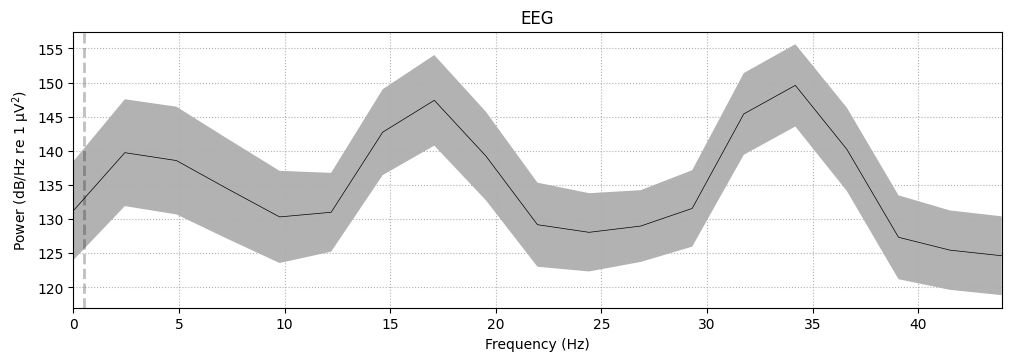

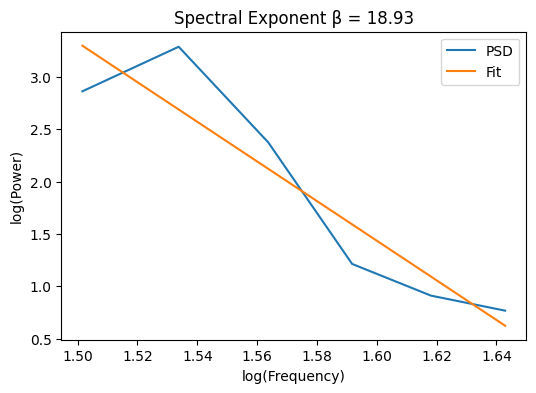

In [30]:
plt.figure(figsize=(6,4))

plt.plot(log_x, log_y, label="PSD")

plt.plot(
    log_x,
    np.polyval(coef, log_x),
    label="Fit"
)

plt.xlabel("log(Frequency)")
plt.ylabel("log(Power)")

plt.title(f"Spectral Exponent β = {beta:.2f}")

plt.legend()

plt.show()

## Preliminary Observation

The spectral slope provides a compact measure of large-scale cortical dynamics.

Steeper spectral decay is commonly associated with reduced neural complexity and unconscious states such as deep sleep and anesthesia.